# Các bước thực hiện
1. Cài đặt và import thư viện
2. Nạp dữ liệu từ `data/split.csv`
3. Xây dựng kiến trúc Advanced Complex CNN
4. Huấn luyện mô hình
5. Vẽ biểu đồ quá trình học
6. Đánh giá trên tập Test
7. Lưu kết quả tổng hợp

Bước 1 – Import thư viện và kiểm tra môi trường

In [ ]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Reshape, Multiply, Add
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Tìm thư mục gốc của dự án (nơi có config.py)
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

print("TensorFlow version:", tf.__version__)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("split.csv exists:", config.SPLIT_CSV_PATH.exists())
print("CPUs available:", tf.config.list_physical_devices("CPU"))

TensorFlow version: 2.21.0
PROJECT_ROOT: d:\Fire-and-smoke-detection-using-D-Fire
split.csv exists: True
GPUs available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


Import dữ liệu từ `data/split.csv`

File `split.csv` chứa đường dẫn tới 4.800 ảnh đã được xử lý sẵn (resize về 224×224).

In [2]:
df = pd.read_csv(config.SPLIT_CSV_PATH)

print("Tổng số hàng:", len(df))
print("Các cột:", list(df.columns))
print()
print(df.groupby(["split", "label"]).size().unstack())

Tổng số hàng: 4800
Các cột: ['filepath', 'processed_filepath', 'split', 'label', 'class_index', 'width', 'height', 'mode', 'image_format', 'file_size_bytes', 'raw_sha256', 'processed_sha256', 'status', 'note']

label  fire  nofire  smoke  smokefire
split                                
test    200     200    200        200
train   800     800    800        800
val     200     200    200        200


In [3]:
# Đọc 1 ảnh từ đường dẫn, trả về (ảnh, nhãn one-hot)
def load_image(filepath, label):
    image = tf.io.decode_jpeg(tf.io.read_file(filepath), channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.ensure_shape(image, [224, 224, 3])
    label = tf.one_hot(label, depth=len(config.CLASS_NAMES))
    return image, label


# Tạo tf.data.Dataset cho train / val / test
def make_dataset(split_name, batch_size=32, shuffle=False):
    split_df = df[df["split"] == split_name].reset_index(drop=True)

    filepaths = [str(PROJECT_ROOT / p) for p in split_df["processed_filepath"]]
    labels = split_df["class_index"].astype(int).tolist()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=config.RANDOM_SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, split_df


BATCH_SIZE = 32

train_ds, train_df = make_dataset("train", batch_size=BATCH_SIZE, shuffle=True)
val_ds,   val_df   = make_dataset("val",   batch_size=BATCH_SIZE)
test_ds,  test_df  = make_dataset("test",  batch_size=BATCH_SIZE)

print(f"Train: {len(train_df)} ảnh  |  Val: {len(val_df)} ảnh  |  Test: {len(test_df)} ảnh")

Train: 3200 ảnh  |  Val: 800 ảnh  |  Test: 800 ảnh


---
## Bước 3 – Xây dựng kiến trúc Advanced Complex CNN

### Tại sao không dùng CNN đơn giản?

CNN đơn giản (chỉ xếp Conv2D liên tiếp) có 2 vấn đề:
- **Vanishing Gradient**: Khi mạng sâu quá 10 tầng, gradient biến mất, mô hình không học được.
- **Không biết tập trung**: Lửa là đốm nhỏ sắc nét, khói là vùng mờ rộng. Cần cơ chế để mạng tự quyết định xem kênh nào quan trọng hơn.

### Giải pháp: 3 kỹ thuật kết hợp

1. **Residual Connection** (đường tắt): Cộng thêm input ban đầu vào output → gradient luôn có đường truyền thẳng.
2. **Squeeze-and-Excitation (SE Block)**: Mạng tự học trọng số cho từng kênh màu → tập trung vào kênh cam/đỏ của lửa.
3. **Global Average Pooling**: Thay Flatten → giảm tham số, chống overfitting.

In [4]:
# Squeeze-and-Excitation: mạng tự học trọng số cho từng kênh
def se_block(x, ratio=16):
    channels = x.shape[-1]

    # Squeeze: (H, W, C) -> (C,)
    s = GlobalAveragePooling2D()(x)

    # Excitation: 2 lớp Dense học trọng số [0, 1] cho mỗi kênh
    s = Dense(channels // ratio, activation="relu", use_bias=False)(s)
    s = Dense(channels, activation="sigmoid", use_bias=False)(s)
    s = Reshape((1, 1, channels))(s)

    # Scale: nhân trọng số vào feature map ban đầu
    return Multiply()([x, s])

In [5]:
# Residual block + SE: output = F(x) + x
def residual_se_block(x, filters, stride=1):
    shortcut = x

    # Nhánh chính: Conv -> BN -> Swish -> Conv -> BN -> SE
    x = Conv2D(filters, (3, 3), strides=stride, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("swish")(x)
    x = Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = se_block(x)

    # Nhánh tắt: Conv 1x1 nếu đổi số kênh hoặc kích thước (để cộng được với nhánh chính)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Cộng 2 nhánh rồi kích hoạt
    x = Add()([x, shortcut])
    return Activation("swish")(x)

In [11]:
# Định nghĩa model
inputs = Input(shape=(224, 224, 3), name="input")

# Stem: Conv stride=2 giảm kích thước 224 -> 112
x = Conv2D(32, (3, 3), strides=2, padding="same", use_bias=False)(inputs)
x = BatchNormalization()(x)
x = Activation("swish")(x)                       # (112, 112, 32)

# Stage 1: 64 filters
x = residual_se_block(x, filters=64, stride=1)   # (112, 112, 64)

# Stage 2: 128 filters, block đầu giảm kích thước 1/2
x = residual_se_block(x, filters=128, stride=2)  # (56, 56, 128)
x = residual_se_block(x, filters=128, stride=1)  # (56, 56, 128)

# Stage 3: 256 filters, block đầu giảm kích thước 1/2
x = residual_se_block(x, filters=256, stride=2)  # (28, 28, 256)
x = residual_se_block(x, filters=256, stride=1)  # (28, 28, 256)

# Global Average Pooling thay cho Flatten: (28, 28, 256) -> (256,)
x = GlobalAveragePooling2D(name="gap")(x)

# Dropout 40% chống overfitting
x = Dropout(0.4)(x)

# Fully connected layer với 128 nodes
x = Dense(128, activation="swish")(x)

# Output layer 4 nodes, dùng softmax để chuyển sang xác suất
outputs = Dense(len(config.CLASS_NAMES), activation="softmax", name="output")(x)

model = Model(inputs=inputs, outputs=outputs, name="Advanced_Custom_CNN")
model.summary()

Model: "Advanced_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 112, 112,  │        864 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 112, 112,  │     18,432 │ activation_11[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 112, 112,  │     36,864 │ activation_12[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 4)         │        256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │        256 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 112, 112,  │      2,048 │ activation_11[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Multiply)          │ 64)               │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 112, 112,  │          0 │ multiply_5[0][0], │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 112, 112,  │          0 │ add_5[0][0]     

 Total params: 2,742,628 (10.46 MB)

 Trainable params: 2,738,340 (10.45 MB)

 Non-trainable params: 4,288 (16.75 KB)

---
## Bước 4 – Compile & Chuẩn bị Callbacks

Trước khi huấn luyện, ta cần:
- **Compile**: Chỉ định Loss function, Optimizer và Metrics cần theo dõi.
- **Callbacks**: Các "cơ chế tự động" chạy sau mỗi epoch để lưu model tốt nhất, dừng sớm khi không tiến bộ, v.v.

In [12]:
# Thư mục và đường dẫn lưu kết quả
RESULTS_DIR = PROJECT_ROOT / "results" / "custom_cnn"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = PROJECT_ROOT / "models" / "custom_cnn_best.keras"
LOG_CSV_PATH    = RESULTS_DIR / "training_log.csv"

# Compile model (label_smoothing giúp model bớt tự tin ở các ca smoke vs smokefire)
model.compile(loss=CategoricalCrossentropy(label_smoothing=0.05),
              optimizer=Adam(learning_rate=1e-3),
              metrics=["accuracy"])

callbacks = [
    # Lưu model khi val_loss thấp nhất
    ModelCheckpoint(str(MODEL_SAVE_PATH), monitor="val_loss",
                    save_best_only=True, mode="min", verbose=1),

    # Dừng sớm nếu val_loss không giảm sau 12 epoch, khôi phục trọng số tốt nhất
    EarlyStopping(monitor="val_loss", patience=12,
                  restore_best_weights=True, verbose=1),

    # Giảm learning rate còn 50% nếu val_loss không giảm sau 4 epoch
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),

    # Ghi loss/accuracy từng epoch ra file CSV
    CSVLogger(str(LOG_CSV_PATH)),
]

print("Model đã được compile. Sẵn sàng huấn luyện.")
print(f"Model sẽ được lưu tại: {MODEL_SAVE_PATH}")
print(f"Log sẽ được lưu tại: {LOG_CSV_PATH}")

Model đã được compile. Sẵn sàng huấn luyện.
Model sẽ được lưu tại: d:\Fire-and-smoke-detection-using-D-Fire\models\custom_cnn_best.keras
Log sẽ được lưu tại: d:\Fire-and-smoke-detection-using-D-Fire\results\custom_cnn\training_log.csv


---
## Bước 5 – Huấn luyện mô hình

Ta chạy tối đa 50 epoch nhưng EarlyStopping sẽ tự dừng sớm hơn nếu model không còn cải thiện.

In [13]:
H = model.fit(train_ds, validation_data=val_ds,
              epochs=50, callbacks=callbacks, verbose=1)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7259 - loss: 0.7914
Epoch 1: val_loss improved from None to 2.20012, saving model to d:\Fire-and-smoke-detection-using-D-Fire\models\custom_cnn_best.keras

Epoch 1: finished saving model to d:\Fire-and-smoke-detection-using-D-Fire\models\custom_cnn_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 686s 7s/step - accuracy: 0.7259 - loss: 0.7914 - val_accuracy: 0.2500 - val_loss: 2.2001 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7903 - loss: 0.6652
Epoch 2: val_loss improved from 2.20012 to 2.14231, saving model to d:\Fire-and-smoke-detection-using-D-Fire\models\custom_cnn_best.keras

Epoch 2: finished saving model to d:\Fire-and-smoke-detection-using-D-Fire\models\custom_cnn_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 803s 8s/step - accuracy: 0.7903 - loss: 0.6652 - val_accuracy: 0.4325 - val_loss: 2.1423 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 

Đã lưu biểu đồ: d:\Fire-and-smoke-detection-using-D-Fire\results\custom_cnn\learning_curves.png


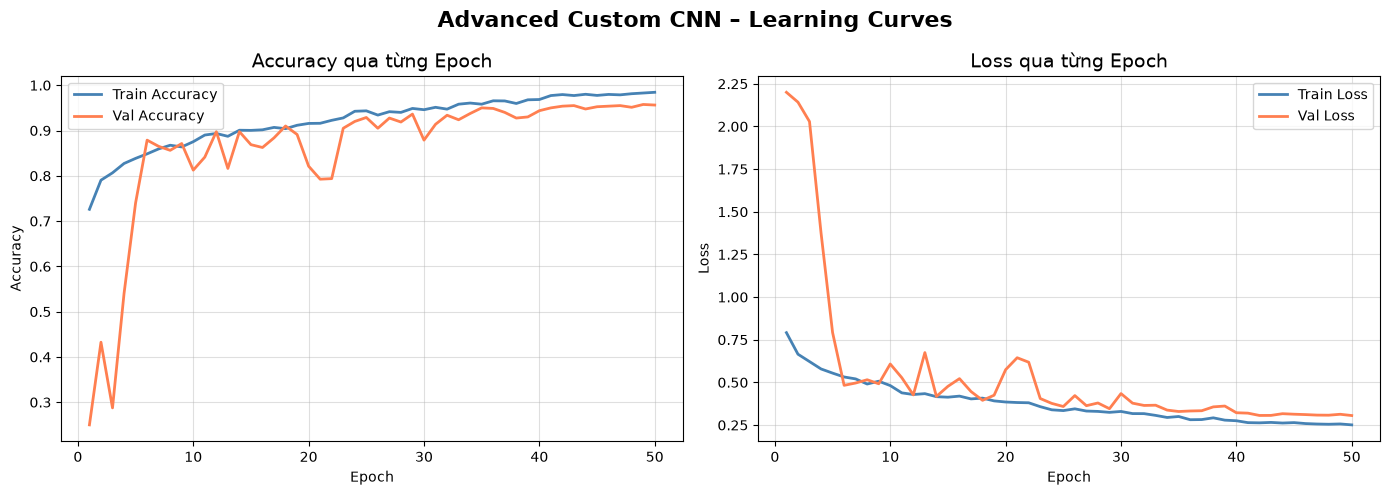

In [14]:
epochs_ran = range(1, len(H.history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_ran, H.history["accuracy"],     label="Train Accuracy", color="steelblue", linewidth=2)
ax1.plot(epochs_ran, H.history["val_accuracy"], label="Val Accuracy",   color="coral",     linewidth=2)
ax1.set_title("Accuracy qua từng Epoch", fontsize=14)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.4)

# Loss
ax2.plot(epochs_ran, H.history["loss"],     label="Train Loss", color="steelblue", linewidth=2)
ax2.plot(epochs_ran, H.history["val_loss"], label="Val Loss",   color="coral",     linewidth=2)
ax2.set_title("Loss qua từng Epoch", fontsize=14)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle("Advanced Custom CNN – Learning Curves", fontsize=16, fontweight="bold")
plt.tight_layout()

save_path = RESULTS_DIR / "learning_curves.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Đã lưu biểu đồ: {save_path}")
plt.show()

In [15]:
# Load lại model tốt nhất do ModelCheckpoint đã lưu
best_model = load_model(str(MODEL_SAVE_PATH))
print("Đã load model tốt nhất từ:", MODEL_SAVE_PATH)

# Dự đoán trên tập test: mỗi hàng là xác suất của 4 lớp
y_pred_probs = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Nhãn thật
y_true = test_df["class_index"].astype(int).values

print(f"\nSố ảnh test: {len(y_true)}")
print(f"Số ảnh đoán đúng: {(y_pred == y_true).sum()}")

Đã load model tốt nhất từ: d:\Fire-and-smoke-detection-using-D-Fire\models\custom_cnn_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 718ms/step

Số ảnh test: 800
Số ảnh đoán đúng: 626


In [16]:
print("CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=config.CLASS_NAMES, digits=4))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fire     0.9766    0.6250    0.7622       200
      nofire     0.9648    0.9600    0.9624       200
       smoke     0.7807    0.7300    0.7545       200
   smokefire     0.5699    0.8150    0.6708       200

    accuracy                         0.7825       800
   macro avg     0.8230    0.7825    0.7875       800
weighted avg     0.8230    0.7825    0.7875       800



Đã lưu confusion matrix: d:\Fire-and-smoke-detection-using-D-Fire\results\custom_cnn\confusion_matrix.png


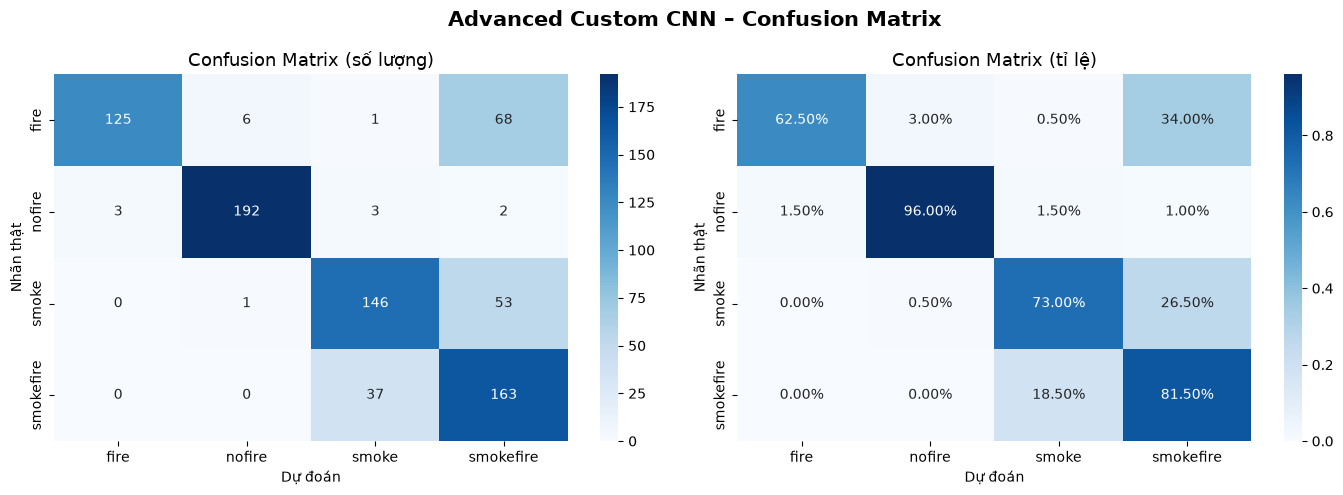

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Số lượng
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=ax1)
ax1.set_title("Confusion Matrix (số lượng)", fontsize=13)
ax1.set_xlabel("Dự đoán")
ax1.set_ylabel("Nhãn thật")

# Tỉ lệ
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=ax2)
ax2.set_title("Confusion Matrix (tỉ lệ)", fontsize=13)
ax2.set_xlabel("Dự đoán")
ax2.set_ylabel("Nhãn thật")

plt.suptitle("Advanced Custom CNN - Confusion Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()

save_path = RESULTS_DIR / "confusion_matrix.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Đã lưu confusion matrix: {save_path}")
plt.show()

Lưu kết quả vào `metrics.json`


In [20]:
metrics = {
    "model_name":                   "Advanced Custom CNN",
    "test_accuracy":                round(float(accuracy_score(y_true, y_pred)), 4),
    "test_macro_f1":                round(float(f1_score(y_true, y_pred, average="macro")), 4),
    "total_parameters":             int(model.count_params()),
    "epochs_trained":               len(H.history["loss"]),
}

metrics_path = RESULTS_DIR / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

for key, value in metrics.items():
    print(f"  {key:<35} : {value}")

print(f"\nĐã lưu metrics tại: {metrics_path}")

  model_name                          : Advanced Custom CNN
  test_accuracy                       : 0.7825
  test_macro_f1                       : 0.7875
  total_parameters                    : 2742628
  epochs_trained                      : 50

Đã lưu metrics tại: d:\Fire-and-smoke-detection-using-D-Fire\results\custom_cnn\metrics.json
